In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from src.baseline import (
    run_baseline_cv,
    plot_baseline_results,
    fit_baseline_model,
    get_permutation_importance,
    plot_permutation_importance,
)
from sklearn.model_selection import train_test_split
from src.consts import (
    RANDOM_STATE,
    TARGET,
    DATA_PATH,
    TEST_SIZE,
    N_JOBS
)
import pandas as pd

In [14]:
df = pd.read_csv(DATA_PATH)

df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [15]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

In [18]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((39073, 14), (9769, 14), (39073,), (9769,))

In [19]:
y_train.value_counts(normalize=True)

income
<=50K    0.76073
>50K     0.23927
Name: proportion, dtype: float64

In [20]:
y_test.value_counts(normalize=True)

income
<=50K    0.760672
>50K     0.239328
Name: proportion, dtype: float64

In [24]:
baseline_results = run_baseline_cv(
    X_train=X_train,
    y_train=y_train,
    n_jobs=N_JOBS,
)

baseline_results

# warning'и прилетают из-за dummy, поэтому не обращаем внимания. dummy нам не интересен

/Users/andrew/PycharmProjects/classification_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrew/PycharmProjects/classification_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/andrew/PycharmProjects/classification_project/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parame

,model,mean_accuracy,std_accuracy,mean_precision_macro,std_precision_macro,mean_recall_macro,std_recall_macro,mean_f1_macro,std_f1_macro,mean_roc_auc,std_roc_auc
3,gradient_boosting,0.865917,0.004611,0.835740,0.009394,0.775424,0.005987,0.798687,0.006454,0.920390,0.003521
2,random_forest,0.852404,0.003385,0.804912,0.005086,0.772114,0.006088,0.786131,0.005426,0.900900,0.004114
1,logistic_regression,0.852302,0.004995,0.807527,0.009202,0.766254,0.005031,0.783216,0.006291,0.906588,0.003655
0,dummy,0.760730,0.000044,0.380365,0.000022,0.500000,0.000000,0.432054,0.000014,0.500000,0.000000


(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Baseline models by mean_f1_macro'}, xlabel='mean_f1_macro', ylabel='model'>)

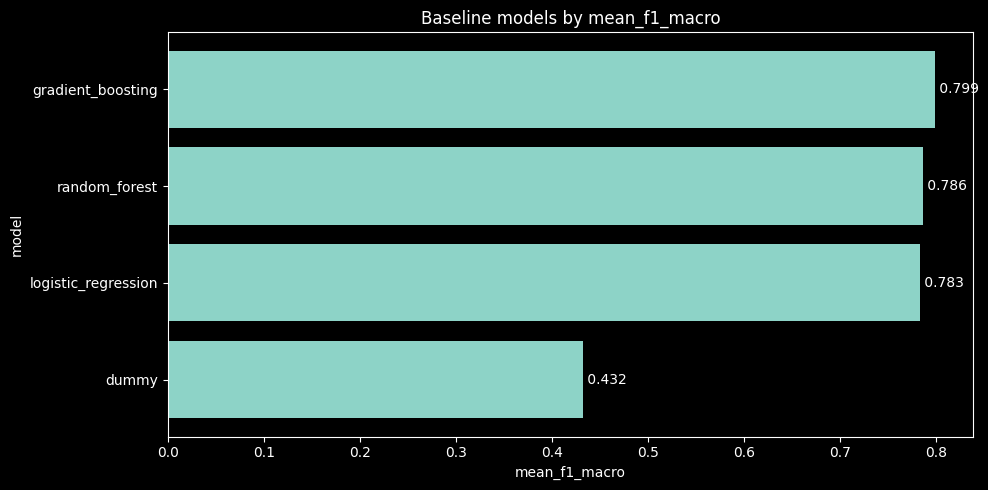

In [25]:
plot_baseline_results(
    baseline_results,
    metric="mean_f1_macro",
)

In [27]:
gb_model = fit_baseline_model(
    X_train=X_train,
    y_train=y_train,
    model_name="gradient_boosting",
)

In [28]:
gb_importance = get_permutation_importance(
    pipeline=gb_model,
    X=X_train,
    y=y_train,
    scoring="f1_macro",
    n_repeats=5,
    n_jobs=2,
)

gb_importance

,feature,importance_mean,importance_std
5,marital-status,0.094552,0.001648
10,capital-gain,0.064413,0.000720
4,educational-num,0.052936,0.000657
0,age,0.034601,0.000883
6,occupation,0.020297,0.001020
11,capital-loss,0.019870,0.000490
12,hours-per-week,0.013955,0.000889
1,workclass,0.003934,0.000357
7,relationship,0.003760,0.000308
9,gender,0.002184,0.000573


(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Permutation importance'}, xlabel='Mean score decrease', ylabel='Feature'>)

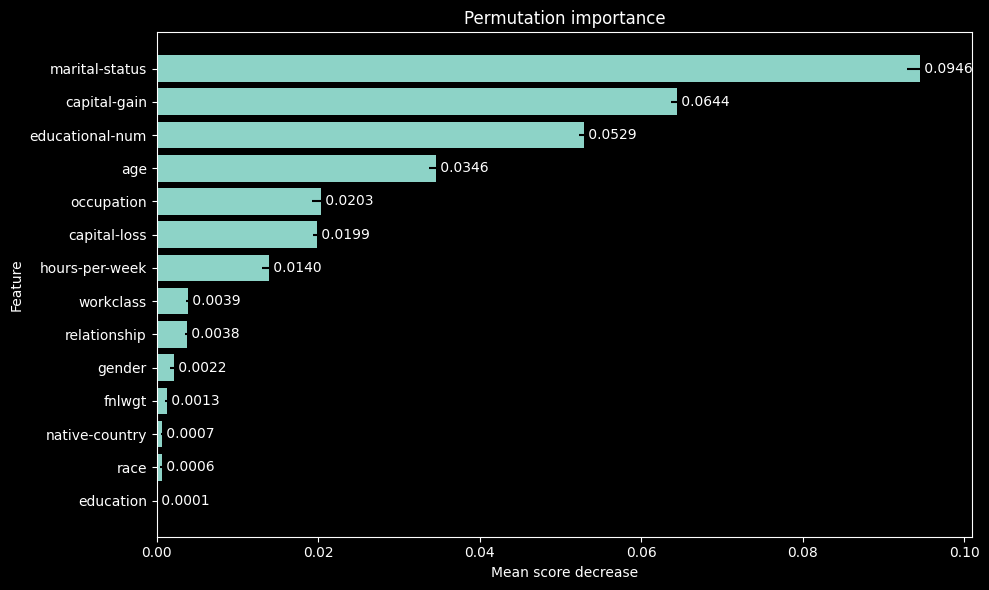

In [29]:
plot_permutation_importance(
    gb_importance,
    top_n=15,
)

In [30]:
lr_model = fit_baseline_model(
    X_train=X_train,
    y_train=y_train,
    model_name="logistic_regression",
)

In [31]:

lr_importance = get_permutation_importance(
    pipeline=lr_model,
    X=X_train,
    y=y_train,
    scoring="f1_macro",
    n_repeats=5,
    n_jobs=2,
)

(<Figure size 1000x600 with 1 Axes>,
 <Axes: title={'center': 'Permutation importance'}, xlabel='Mean score decrease', ylabel='Feature'>)

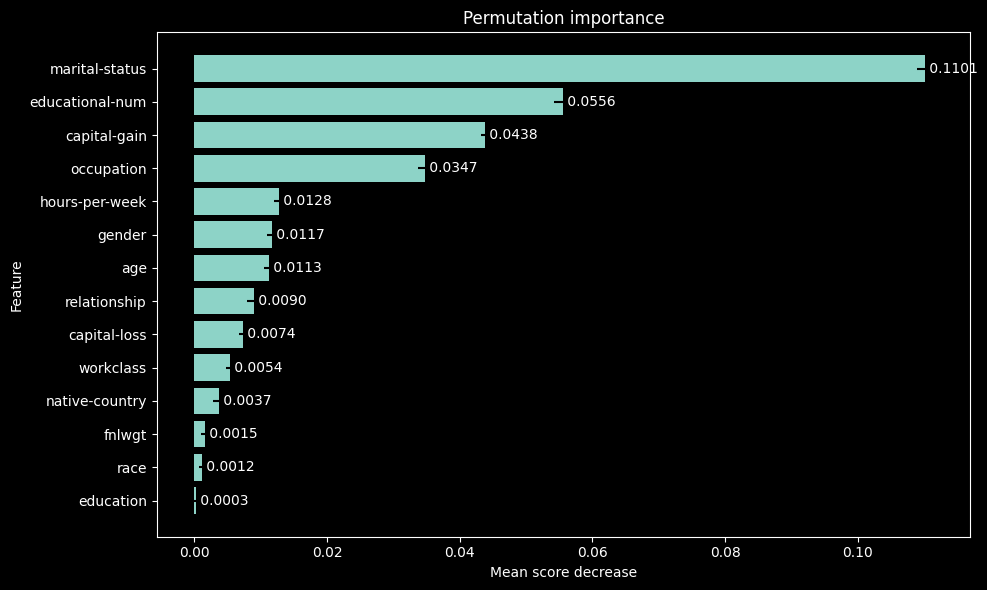

In [32]:
plot_permutation_importance(lr_importance, top_n=15)